In [25]:
# Data visualization notebook that uses the master dataset to generate
# monthly and yearly box-and-whisker plots for selected parameters using
# the `month_year_boxplot` function from `plot_functions.ipynb`.
# The notebook also includes density plots comparing pairs of parameters
# to visualize relationships and distribution overlap.

import numpy as np
from astropy.io import fits
from astropy.table import Table
from datetime import datetime
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
%run plot_functions.ipynb

In [14]:
file = 'path/to/master_file'
with fits.open(file) as hdul:
    data = Table(hdul[1].data)
    print(hdul[1].header)

XTENSION= 'BINTABLE'           / binary table extension                         BITPIX  =                    8 / array data type                                NAXIS   =                    2 / number of array dimensions                     NAXIS1  =                  131 / length of dimension 1                          NAXIS2  =               272973 / length of dimension 2                          PCOUNT  =                    0 / number of group parameters                     GCOUNT  =                    1 / number of groups                               TFIELDS =                   15 / number of table fields                         TTYPE1  = 'datetime'                                                            TFORM1  = '19A     '                                                            TTYPE2  = '500m    '                                                            TFORM2  = 'D       '                                                            TTYPE3  = '1km     '                    

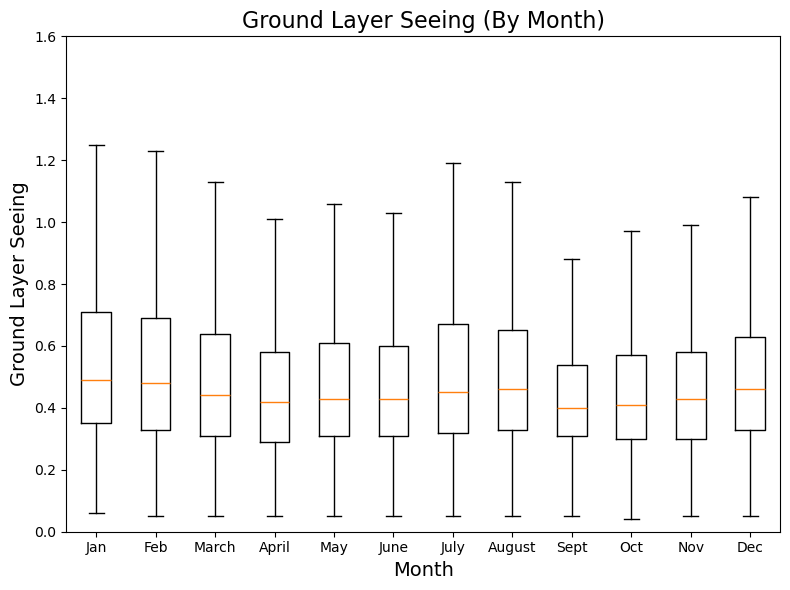

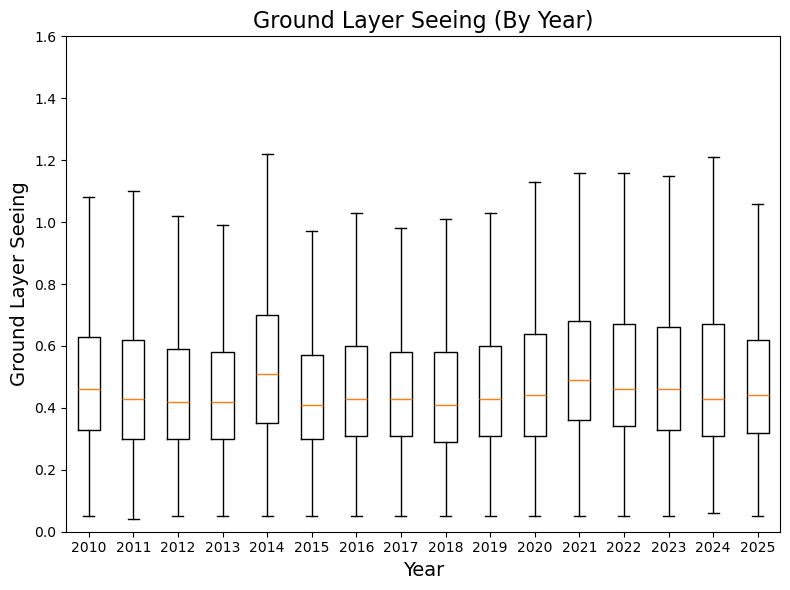

In [26]:
month_year_boxplot('ground_layer', 'Ground Layer')

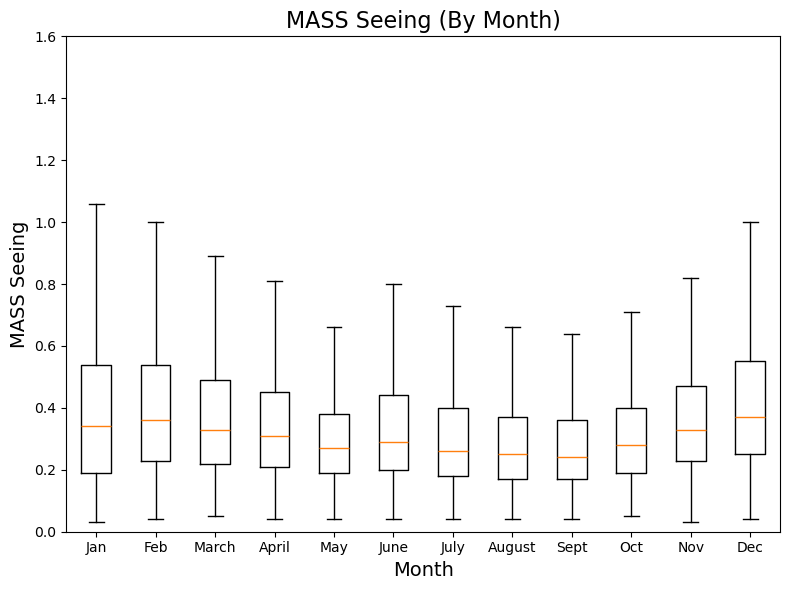

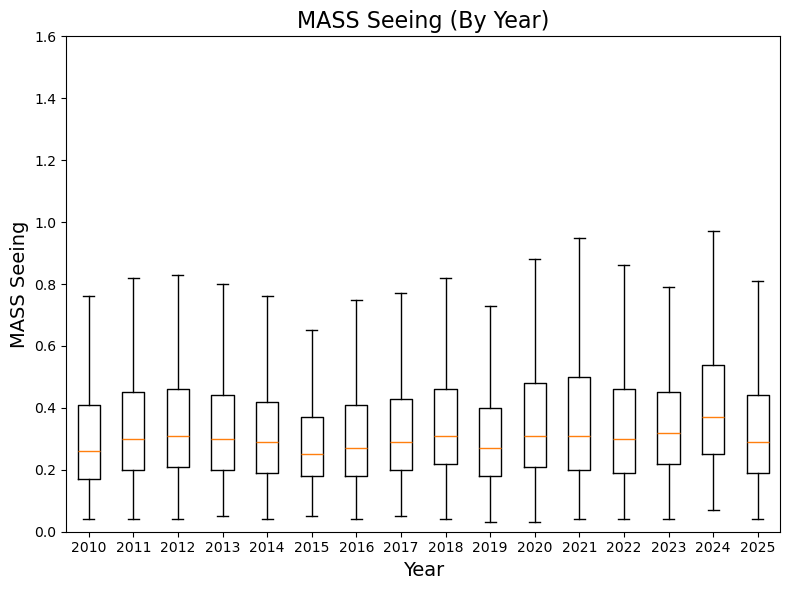

In [24]:
month_year_boxplot('mass_val', 'MASS')

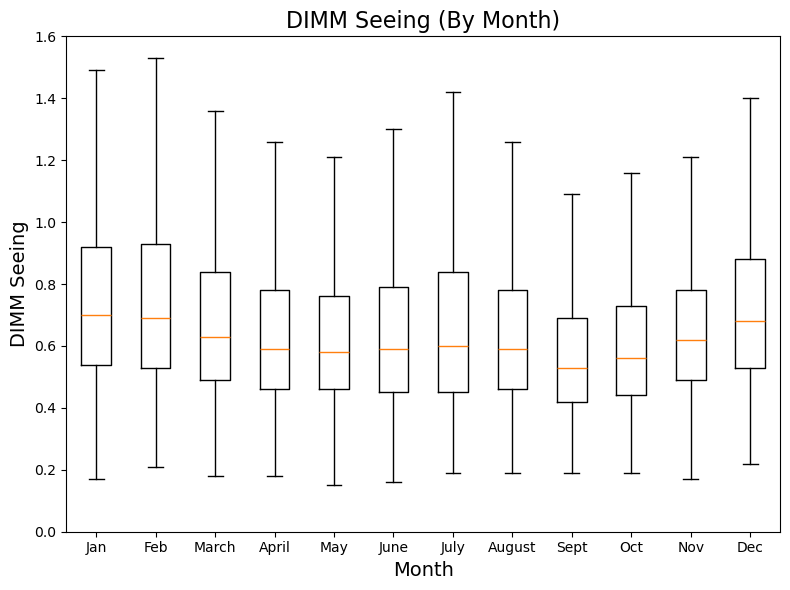

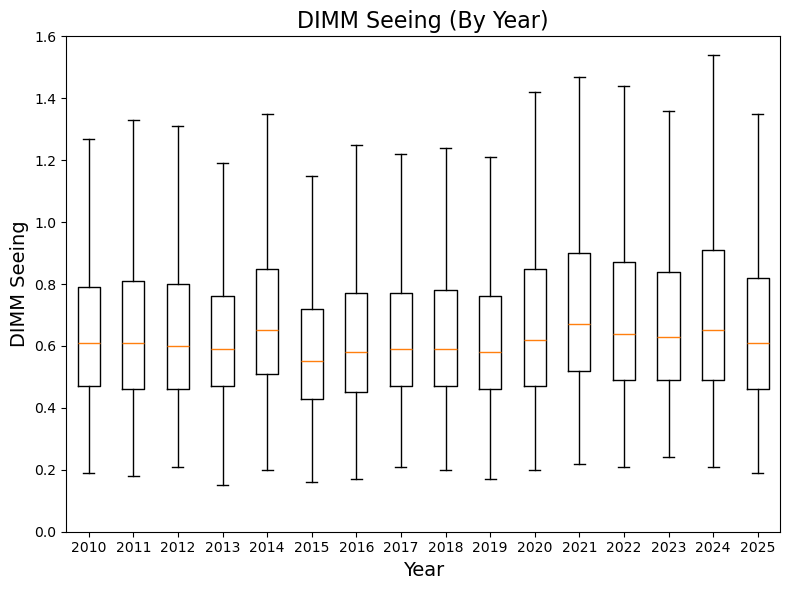

In [22]:
month_year_boxplot('dimm_val', 'DIMM')

In [27]:
table = Table.read("master_file.fits")

ground_layer = table["ground_layer"]
wind_speed = table["wind_speed"]
wind_dir = table["wind_dir"]
dimm_val = table["dimm_val"]
mass_val = table["mass_val"]
temp = table["temp"]
humidity = table["humidity"]
pressure = table["pressure"]

five = table['500m']

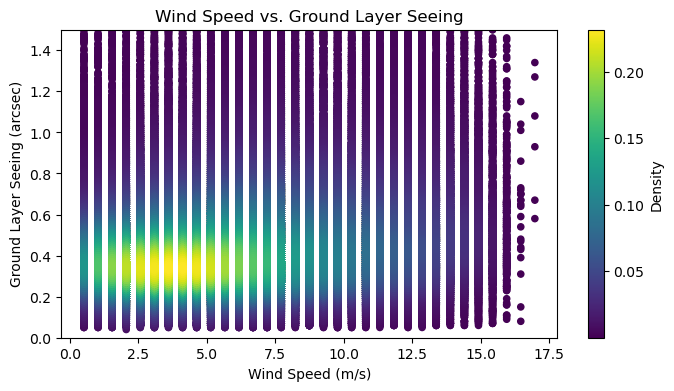

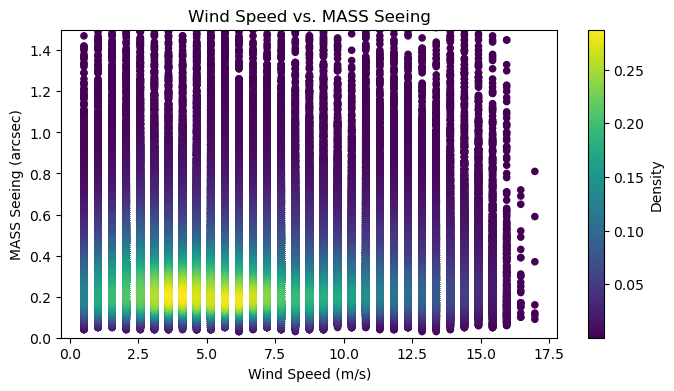

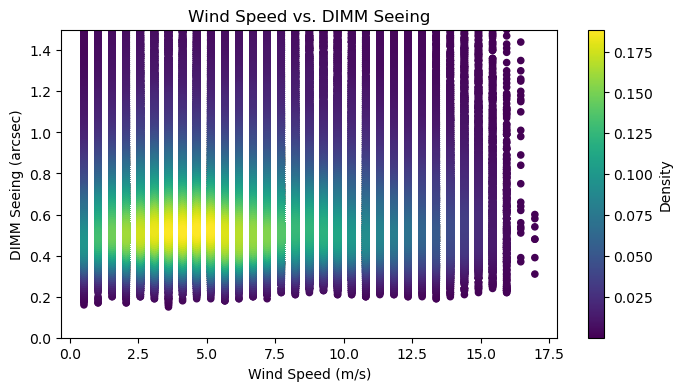

In [16]:
# Ground Layer vs. Wind Speed
plt.figure(figsize=(8,4))

# Estimate density
xy = np.vstack([wind_speed, ground_layer])
z = gaussian_kde(xy)(xy)

# Sort points by density so high-density points are plotted on top
idx = z.argsort()
wind_speed, ground_layer, z = wind_speed[idx], ground_layer[idx], z[idx]

# Scatter plot with density coloring
sc = plt.scatter(wind_speed, ground_layer, c=z, s=20, cmap="viridis")
plt.colorbar(sc, label="Density")
plt.title('Wind Speed vs. Ground Layer Seeing')
plt.ylabel("Ground Layer Seeing (arcsec)")
plt.xlabel("Wind Speed (m/s)")
plt.ylim(0,1.5)
plt.savefig('gl_wind_speed.png')
plt.show()

# MASS Seeing vs. Wind Speed
plt.figure(figsize=(8,4))

# Estimate density
xy = np.vstack([wind_speed, mass_val])
z = gaussian_kde(xy)(xy)

# Sort points by density so high-density points are plotted on top
idx = z.argsort()
wind_speed, mass_val, z = wind_speed[idx], mass_val[idx], z[idx]

# Scatter plot with density coloring
sc = plt.scatter(wind_speed, mass_val, c=z, s=20, cmap="viridis")
plt.colorbar(sc, label="Density")
plt.title('Wind Speed vs. MASS Seeing')
plt.ylabel("MASS Seeing (arcsec)")
plt.xlabel("Wind Speed (m/s)")
plt.ylim(0,1.5)
plt.savefig('mass_wind_speed.png')
plt.show()

# DIMM Seeing vs. Wind Speed
plt.figure(figsize=(8,4))

# Estimate density
xy = np.vstack([wind_speed, dimm_val])
z = gaussian_kde(xy)(xy)

# Sort points by density so high-density points are plotted on top
idx = z.argsort()
wind_speed, dimm_val, z = wind_speed[idx], dimm_val[idx], z[idx]

# Scatter plot with density coloring
sc = plt.scatter(wind_speed, dimm_val, c=z, s=20, cmap="viridis")
plt.colorbar(sc, label="Density")
plt.title('Wind Speed vs. DIMM Seeing')
plt.ylabel("DIMM Seeing (arcsec)")
plt.xlabel("Wind Speed (m/s)")
plt.ylim(0,1.5)
plt.savefig('dimm_wind_speed.png')
plt.show()

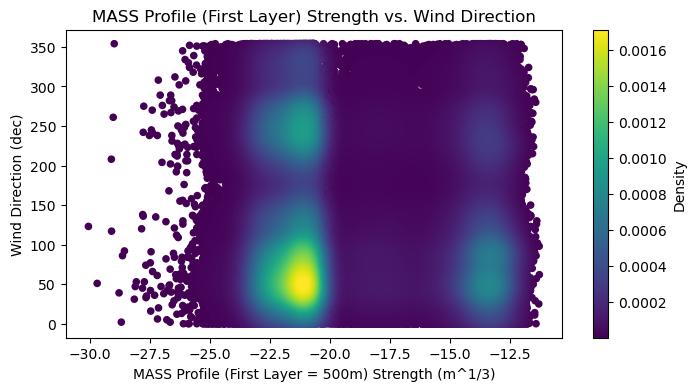

In [31]:
log_five = np.log10(five)
# Ground Layer vs. Temp
plt.figure(figsize=(8,4))

# Estimate density
xy = np.vstack([log_five, wind_dir])
z = gaussian_kde(xy)(xy)

# Sort points by density so high-density points are plotted on top
idx = z.argsort()
log_five, wind_dir, z = log_five[idx], wind_dir[idx], z[idx]

# Scatter plot with density coloring
sc = plt.scatter(log_five, wind_dir, c=z, s=20, cmap="viridis")
plt.colorbar(sc, label="Density")
plt.title('MASS Profile (First Layer) Strength vs. Wind Direction')
plt.xlabel("MASS Profile (First Layer = 500m) Strength (m^1/3)")
plt.ylabel("Wind Direction (dec)")
#plt.xlim(0,.05e-12)
#plt.savefig('masspro_wind_dir.png')
plt.show()

# # MASS Seeing vs. Temp
# plt.figure(figsize=(8,4))

# # Estimate density
# xy = np.vstack([mass_val, temp])
# z = gaussian_kde(xy)(xy)

# # Sort points by density so high-density points are plotted on top
# idx = z.argsort()
# mass_val, temp, z = mass_val[idx], temp[idx], z[idx]

# # Scatter plot with density coloring
# sc = plt.scatter(mass_val, temp, c=z, s=20, cmap="viridis")
# plt.colorbar(sc, label="Density")
# plt.title('Wind Direction vs. DIMM Seeing')
# plt.xlabel("MASS Seeing (arcsec)")
# plt.ylabel("Temperature (°C)")
# plt.savefig('mass_temp.png')
# plt.show()

# # DIMM Seeing vs. Temp
# plt.figure(figsize=(8,4))

# # Estimate density
# xy = np.vstack([dimm_val, temp])
# z = gaussian_kde(xy)(xy)

# # Sort points by density so high-density points are plotted on top
# idx = z.argsort()
# dimm_val, temp, z = dimm_val[idx], temp[idx], z[idx]

# # Scatter plot with density coloring
# sc = plt.scatter(dimm_val, temp, c=z, s=20, cmap="viridis")
# plt.colorbar(sc, label="Density")
# plt.title('Wind Direction vs. DIMM Seeing')
# plt.xlabel("DIMM Seeing (arcsec)")
# plt.ylabel("Temperature (°C)")
# plt.savefig('dimm_temp.png')
# plt.show()

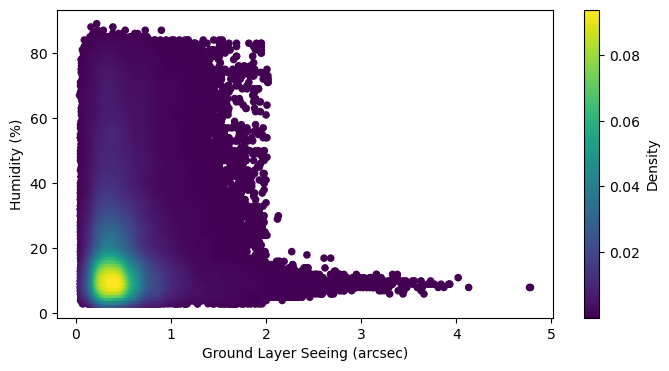

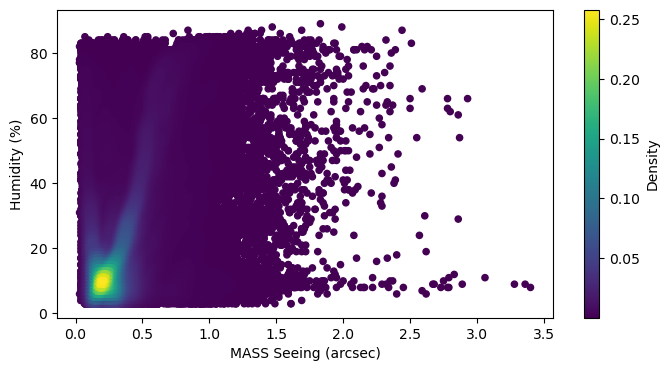

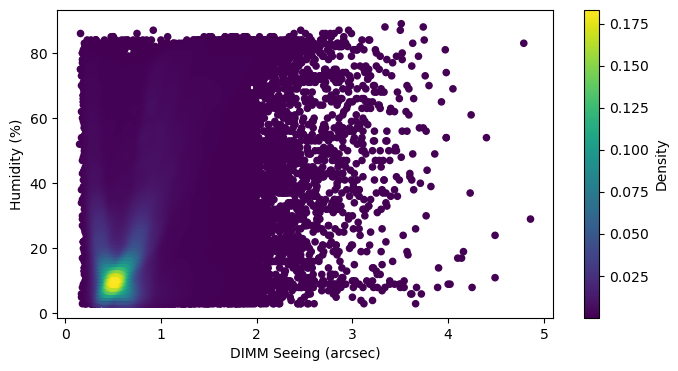

In [9]:
# Ground Layer vs. Humidity
plt.figure(figsize=(8,4))

# Estimate density
xy = np.vstack([ground_layer, humidity])
z = gaussian_kde(xy)(xy)

# Sort points by density so high-density points are plotted on top
idx = z.argsort()
ground_layer, humidity, z = ground_layer[idx], humidity[idx], z[idx]

# Scatter plot with density coloring
sc = plt.scatter(ground_layer, humidity, c=z, s=20, cmap="viridis")
plt.colorbar(sc, label="Density")
plt.xlabel("Ground Layer Seeing (arcsec)")
plt.ylabel("Humidity (%)")
plt.savefig('gl_humidity.png')
plt.show()

# MASS Seeing vs. Humidity
plt.figure(figsize=(8,4))

# Estimate density
xy = np.vstack([mass_val, humidity])
z = gaussian_kde(xy)(xy)

# Sort points by density so high-density points are plotted on top
idx = z.argsort()
mass_val, humidity, z = mass_val[idx], humidity[idx], z[idx]

# Scatter plot with density coloring
sc = plt.scatter(mass_val, humidity, c=z, s=20, cmap="viridis")
plt.colorbar(sc, label="Density")
plt.xlabel("MASS Seeing (arcsec)")
plt.ylabel("Humidity (%)")
plt.savefig('mass_humidity.png')
plt.show()

# DIMM Seeing vs. Humidity
plt.figure(figsize=(8,4))

# Estimate density
xy = np.vstack([dimm_val, humidity])
z = gaussian_kde(xy)(xy)

# Sort points by density so high-density points are plotted on top
idx = z.argsort()
dimm_val, humidity, z = dimm_val[idx], humidity[idx], z[idx]

# Scatter plot with density coloring
sc = plt.scatter(dimm_val, humidity, c=z, s=20, cmap="viridis")
plt.colorbar(sc, label="Density")
plt.xlabel("DIMM Seeing (arcsec)")
plt.ylabel("Humidity (%)")
plt.savefig('dimm_humidity.png')
plt.show()

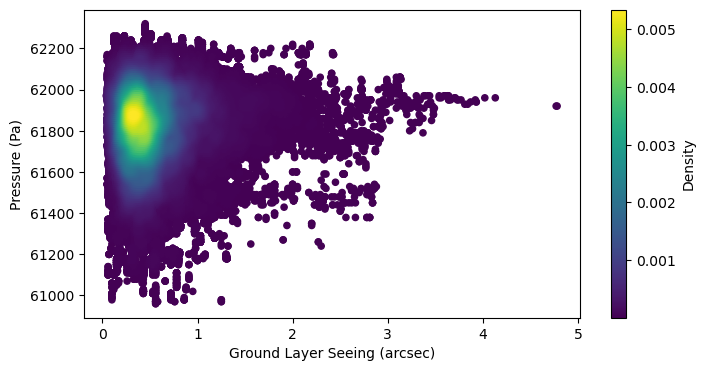

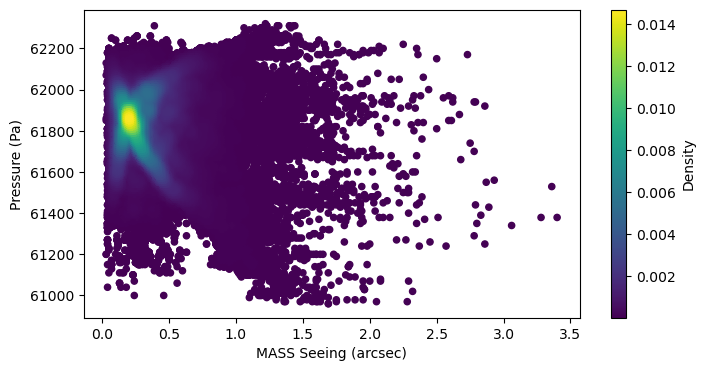

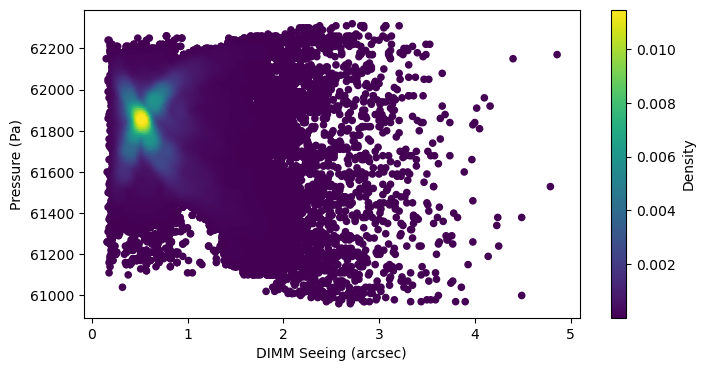

In [10]:
# Ground Layer vs. Pressure
plt.figure(figsize=(8,4))

# Estimate density
xy = np.vstack([ground_layer, pressure])
z = gaussian_kde(xy)(xy)

# Sort points by density so high-density points are plotted on top
idx = z.argsort()
ground_layer, pressure, z = ground_layer[idx], pressure[idx], z[idx]

# Scatter plot with density coloring
sc = plt.scatter(ground_layer, pressure, c=z, s=20, cmap="viridis")
plt.colorbar(sc, label="Density")
plt.xlabel("Ground Layer Seeing (arcsec)")
plt.ylabel("Pressure (Pa)")
plt.savefig('gl_pressure.png')
plt.show()

# MASS Seeing vs. Pressure
plt.figure(figsize=(8,4))

# Estimate density
xy = np.vstack([mass_val, pressure])
z = gaussian_kde(xy)(xy)

# Sort points by density so high-density points are plotted on top
idx = z.argsort()
mass_val, pressure, z = mass_val[idx], pressure[idx], z[idx]

# Scatter plot with density coloring
sc = plt.scatter(mass_val, pressure, c=z, s=20, cmap="viridis")
plt.colorbar(sc, label="Density")
plt.xlabel("MASS Seeing (arcsec)")
plt.ylabel("Pressure (Pa)")
plt.savefig('mass_pressure.png')
plt.show()

# DIMM Seeing vs. Pressure
plt.figure(figsize=(8,4))

# Estimate density
xy = np.vstack([dimm_val, pressure])
z = gaussian_kde(xy)(xy)

# Sort points by density so high-density points are plotted on top
idx = z.argsort()
dimm_val, pressure, z = dimm_val[idx], pressure[idx], z[idx]

# Scatter plot with density coloring
sc = plt.scatter(dimm_val, pressure, c=z, s=20, cmap="viridis")
plt.colorbar(sc, label="Density")
plt.xlabel("DIMM Seeing (arcsec)")
plt.ylabel("Pressure (Pa)")
plt.savefig('dimm_pressure.png')
plt.show()

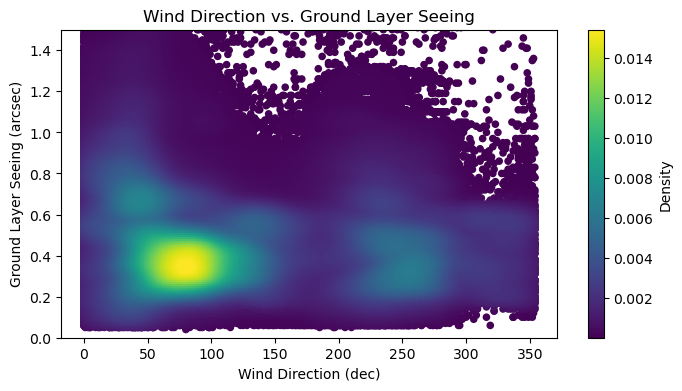

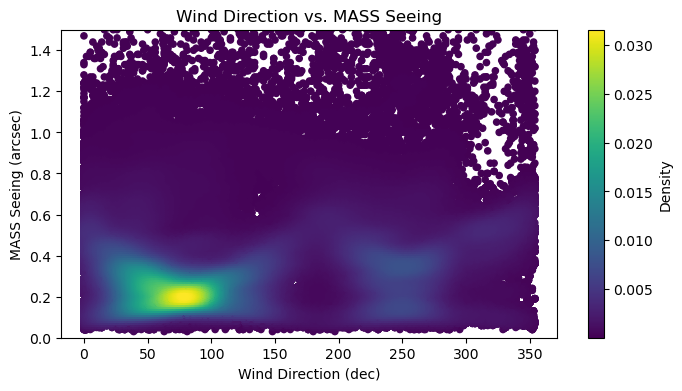

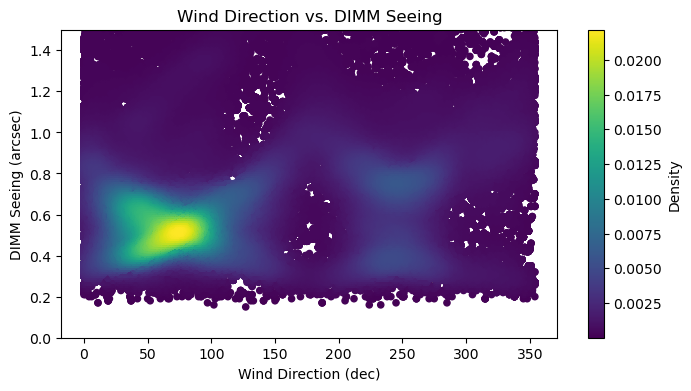

In [17]:
# Ground Layer vs. Wind Direction
plt.figure(figsize=(8,4))

# Estimate density
xy = np.vstack([wind_dir, ground_layer])
z = gaussian_kde(xy)(xy)

# Sort points by density so high-density points are plotted on top
idx = z.argsort()
wind_dir, ground_layer, z = wind_dir[idx], ground_layer[idx], z[idx]

# Scatter plot with density coloring
sc = plt.scatter(wind_dir, ground_layer, c=z, s=20, cmap="viridis")
plt.colorbar(sc, label="Density")
plt.title('Wind Direction vs. Ground Layer Seeing')
plt.ylabel("Ground Layer Seeing (arcsec)")
plt.xlabel("Wind Direction (dec)")
plt.ylim(0,1)
plt.savefig('gl_wind_dir.png')
plt.show()

# MASS Seeing vs. Wind Direction
plt.figure(figsize=(8,4))

# Estimate density
xy = np.vstack([wind_dir, mass_val])
z = gaussian_kde(xy)(xy)

# Sort points by density so high-density points are plotted on top
idx = z.argsort()
wind_dir, mass_val, z = wind_dir[idx], mass_val[idx], z[idx]

# Scatter plot with density coloring
sc = plt.scatter(wind_dir, mass_val, c=z, s=20, cmap="viridis")
plt.colorbar(sc, label="Density")
plt.title('Wind Direction vs. MASS Seeing')
plt.ylabel("MASS Seeing (arcsec)")
plt.xlabel("Wind Direction (dec)")
plt.ylim(0,1)
plt.savefig('mass_wind_dir.png')
plt.show()

# # DIMM Seeing vs. Wind Direction
# plt.figure(figsize=(8,4))

# # Estimate density
# xy = np.vstack([wind_dir, dimm_val])
# z = gaussian_kde(xy)(xy)

# # Sort points by density so high-density points are plotted on top
# idx = z.argsort()
# wind_dir, dimm_val, z = wind_dir[idx], dimm_val[idx], z[idx]

# # Scatter plot with density coloring
# sc = plt.scatter(wind_dir, dimm_val, c=z, s=20, cmap="viridis")
# plt.colorbar(sc, label="Density")
# plt.title('Wind Direction vs. DIMM Seeing')
# plt.ylabel("DIMM Seeing (arcsec)")
# plt.xlabel("Wind Direction (dec)")
# plt.ylim(0,1.5)
# plt.savefig('dimm_wind_dir.png')
# plt.show()